<a href="https://colab.research.google.com/github/AliaF123/Laptop_Review/blob/main/laptop_review_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import warnings

from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from nltk.sentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
df = pd.read_csv("final.csv")

In [4]:
#preview data
df.head(10)

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review,final_review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Perfect product!,"Loved it, it's my first MacBook that I earned ...","Perfect product! Loved it, it's my first MacBo..."
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Fabulous!,Battery lasted longer than my first relationsh...,Fabulous! Battery lasted longer than my first ...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Fabulous!,Such a great deal.. very happy with the perfor...,Fabulous! Such a great deal.. very happy with ...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,4,Delightful,"Awesome build quality and very good display, b...",Delightful Awesome build quality and very good...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Awesome,When i ordered and came to know about seller r...,Awesome When i ordered and came to know about ...
5,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Super!,Super product,Super! Super product
6,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Super!,Go for it..its awesome,Super! Go for it..its awesome
7,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Mind-blowing purchase,"Best , best and best 🫶🏻👑🍎","Mind-blowing purchase Best , best and best 🫶🏻👑🍎"
8,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Just wow!,Its really very good and compact device.,Just wow! Its really very good and compact dev...
9,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Brilliant,"Superb built quality, Amazing performance and ...","Brilliant Superb built quality, Amazing perfor..."


In [5]:
df['product_name']

,product_name
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
...,...
25933,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25934,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25935,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25936,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...


In [6]:
print("Rows, Columns:", df.shape)

Rows, Columns: (25938, 8)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25938 entries, 0 to 25937
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    25938 non-null  object 
 1   overall_rating  25938 non-null  float64
 2   no_ratings      25938 non-null  object 
 3   no_reviews      25938 non-null  object 
 4   rating          25938 non-null  int64  
 5   title           25938 non-null  object 
 6   review          25938 non-null  object 
 7   final_review    24113 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.6+ MB


In [8]:
df.isnull().sum()

,0
product_name,0
overall_rating,0
no_ratings,0
no_reviews,0
rating,0
title,0
review,0
final_review,1825


In [9]:
df.duplicated().sum()

np.int64(7122)

In [17]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [18]:
def clean_review(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [19]:
df['clean_review'] = df['review'].apply(clean_review)

In [20]:
df['clean_review']

,clean_review
0,loved first macbook earned hardwork
1,battery lasted longer first relationship day l...
2,great deal happy performance battery lifeorigi...
3,awesome build quality good display battery cam...
4,ordered came know seller reviewi scared condit...
...,...
25933,great balance speed portability reliability ev...
25934,build quality feel premium laptop handle multi...
25935,great balance speed portability reliability ev...
25936,laptop performs well task although battery cou...


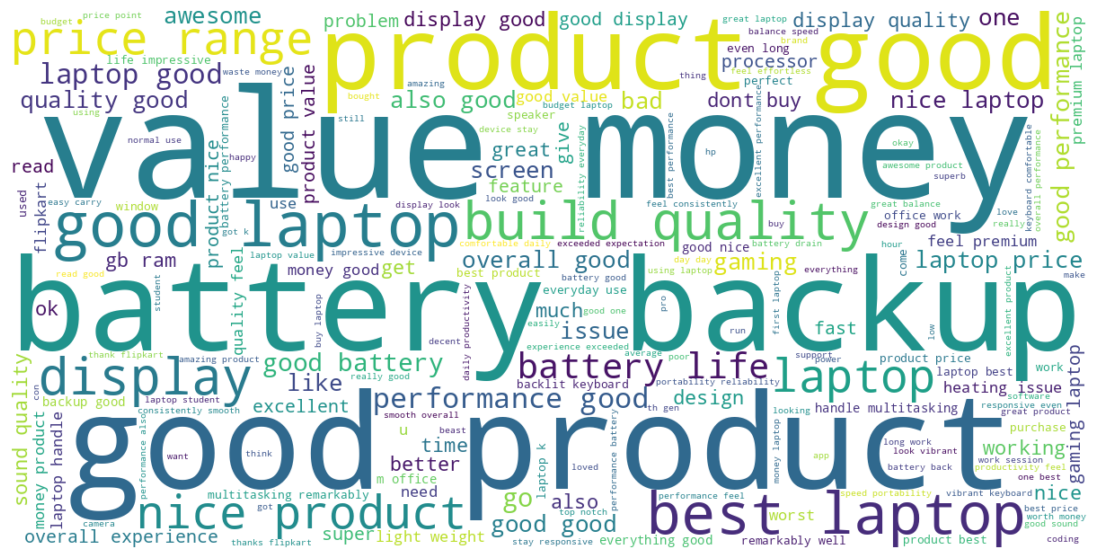

In [21]:

# Select the column that has reviews
text_column = "clean_review"

# Combine all reviews into one big text
text = " ".join(df[text_column].dropna().astype(str))

# Create word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords={"the","is","and","a","to","it","this","was","for"}
).generate(text)

# Show result
plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [22]:
# Aspect Dictionary
aspect_dict = {

    "performance":[
        "performance",
        "speed",
        "fast",
        "slow",
        "lag",
        "processor",
        "cpu",
        "multitasking"
    ],

    "battery":[
        "battery",
        "charging",
        "charge",
        "backup",
        "power"
    ],

    "display":[
        "display",
        "screen",
        "brightness",
        "resolution",
        "color"
    ],

    "keyboard":[
        "keyboard",
        "typing",
        "trackpad",
        "touchpad"
    ],

    "heating":[
        "heat",
        "heating",
        "thermal",
        "temperature"
    ],

    "price":[
        "price",
        "cost",
        "expensive",
        "cheap",
        "value"
    ],

    "build":[
        "build",
        "design",
        "quality",
        "durable"
    ],

    "portability":[
        "weight",
        "portable",
        "lightweight"
    ]
}

In [23]:
#Keyword Aspect Extraction
def extract_keyword_aspects(text):

    tokens = set(text.split())

    aspects_found = []

    for aspect, keywords in aspect_dict.items():

        if len(tokens.intersection(keywords)) > 0:
            aspects_found.append(aspect)

    return aspects_found

In [24]:
df["keyword_aspects"] = (
    df["clean_review"]
    .apply(extract_keyword_aspects)
)

In [ ]:
# Sentence BERT Setup
model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
aspect_descriptions = {

    "performance":
        "laptop performance cpu speed multitasking gaming",

    "battery":
        "battery life charging backup power",

    "display":
        "screen display brightness resolution colors",

    "keyboard":
        "keyboard typing trackpad touchpad keys",

    "heating":
        "heating thermal cooling temperature",

    "price":
        "price value money expensive cheap",

    "build":
        "build quality design durability",

    "portability":
        "portable lightweight weight travel"
}

In [ ]:
#Precompute Aspect Embedding
aspect_names = list(
    aspect_descriptions.keys()
)

aspect_embeddings = model.encode(
    list(aspect_descriptions.values()),
    convert_to_numpy=True
)

In [ ]:
#Batch Encode Reviews
review_embeddings = model.encode(
    df["clean_review"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

In [ ]:
#Semantic Aspect Assignment
similarity_matrix = cosine_similarity(
    review_embeddings,
    aspect_embeddings
)

In [ ]:
def assign_semantic_aspects(
    similarity_row,
    threshold=0.35
):

    idx = np.where(
        similarity_row >= threshold
    )[0]

    return [
        aspect_names[i]
        for i in idx
    ]

In [ ]:
df["semantic_aspects"] = [

    assign_semantic_aspects(row)

    for row in similarity_matrix
]

In [ ]:
#Vader Sentiment
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def aspect_sentiment(text):
    return sia.polarity_scores(text)["compound"]

df["sentiment"] = df["clean_review"].apply(aspect_sentiment)

In [ ]:
aspect_rows = []

for _, row in df.iterrows():
    for aspect in row["aspects"]:
        aspect_rows.append([aspect, row["sentiment"]])

aspect_df = pd.DataFrame(aspect_rows, columns=["aspect", "sentiment"])

In [ ]:
#Sentiment Label
def sentiment_label(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    return "Neutral"

In [ ]:
df["sentiment_label"] = (
    df["sentiment_score"]
    .apply(sentiment_label)
)

In [ ]:
# Create ABSA Table
absa_rows = []

for _, row in df.iterrows():

    for aspect in row["semantic_aspects"]:

        absa_rows.append({

            "product":
                row["product_name"],

            "aspect":
                aspect,

            "sentiment_score":
                row["sentiment_score"],

            "sentiment":
                row["sentiment_label"]
        })

In [ ]:
absa_df = pd.DataFrame(
    absa_rows
)

In [ ]:
Aspect Frequency
aspect_freq = (
    absa_df["aspect"]
    .value_counts()
)

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=aspect_freq.index,
    y=aspect_freq.values
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
Average Aspect Sentiment
aspect_sentiment = (

    absa_df
    .groupby("aspect")
    ["sentiment_score"]
    .mean()
    .sort_values()
)

In [ ]:
plt.figure(figsize=(10,5))

aspect_sentiment.plot(
    kind="bar"
)

plt.title(
    "Average Sentiment by Aspect"
)

plt.show()

In [ ]:
Product * Aspect Heatmap
pivot = absa_df.pivot_table(

    index="product",

    columns="aspect",

    values="sentiment_score",

    aggfunc="mean"
)

In [ ]:
plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0
)

plt.title(
    "Product vs Aspect Sentiment"
)

plt.show()